### Numerical ODE solver 

We can use Runge-Kutta 4 to solve ODE

#### First Order ODE

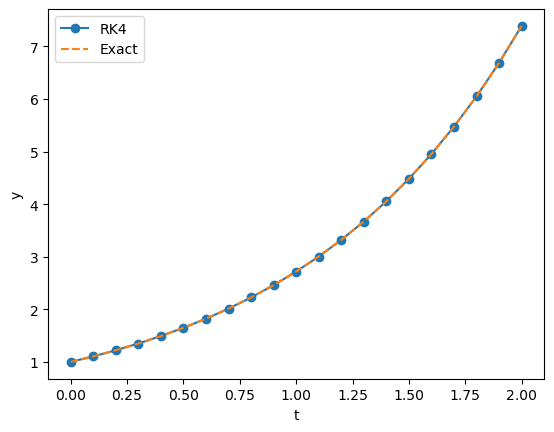

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def rk4(f, t0, y0, t_end, h):
    t_values = np.arange(t0, t_end + h, h)
    y_values = np.zeros(len(t_values))

    y_values[0] = y0

    for n in range(len(t_values) - 1):
        t = t_values[n]
        y = y_values[n]

        k1 = f(t, y)
        k2 = f(t + h / 2, y + h * k1 / 2)
        k3 = f(t + h / 2, y + h * k2 / 2)
        k4 = f(t + h, y + h * k3)

        y_values[n + 1] = y + h * (k1 + 2*k2 + 2*k3 + k4) / 6

    return t_values, y_values


# Solve for example: dy/dt = y
def f(t, y):
    return y


t0 = 0
y0 = 1
t_end = 2
h = 0.1

t, y_rk4 = rk4(f, t0, y0, t_end, h)

y_exact = np.exp(t)

plt.plot(t, y_rk4, "o-", label="RK4")
plt.plot(t, y_exact, "--", label="Exact")
plt.xlabel("t")
plt.ylabel("y")
plt.legend()
plt.show()

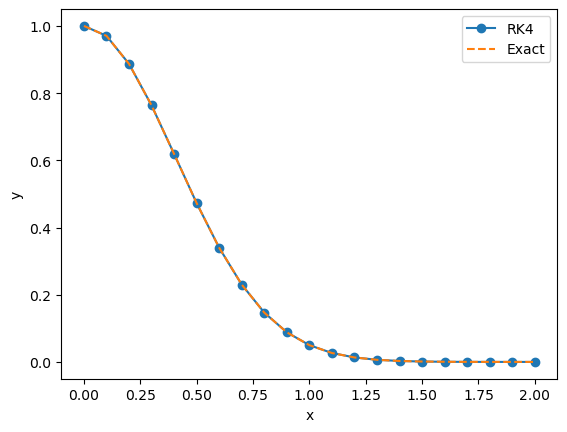

In [6]:
# Solve for example: dy/dt = -6xy
def f(x, y):
    return -6 * x * y


x0 = 0
y0 = 1
x_end = 2
h = 0.1

x, y_rk4 = rk4(f, x0, y0, x_end, h)

y_exact = np.exp(-3 * x**2)

plt.plot(x, y_rk4, "o-", label="RK4")
plt.plot(x, y_exact, "--", label="Exact")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

#### Second Order ODE

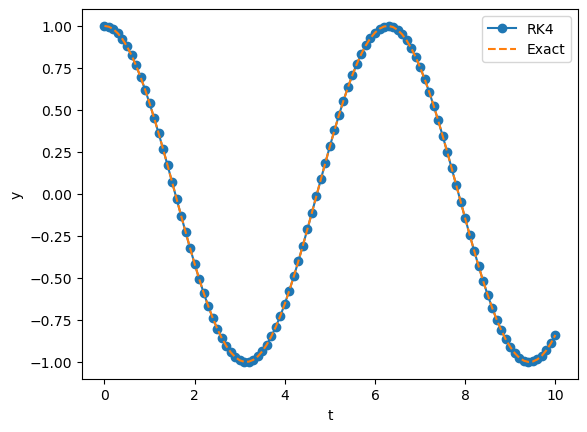

In [10]:
def rk4_system(f, t0, Y0, t_end, h):
    t_values = np.arange(t0, t_end + h, h)
    Y_values = np.zeros((len(t_values), len(Y0)))

    Y_values[0] = Y0

    for n in range(len(t_values) - 1):
        t = t_values[n]
        Y = Y_values[n]

        k1 = f(t, Y)
        k2 = f(t + h / 2, Y + h * k1 / 2)
        k3 = f(t + h / 2, Y + h * k2 / 2)
        k4 = f(t + h, Y + h * k3)

        Y_values[n + 1] = Y + h * (k1 + 2*k2 + 2*k3 + k4) / 6

    return t_values, Y_values


def harmonic_oscillator(t, Y):
    y, v = Y

    dydt = v
    dvdt = -y

    return np.array([dydt, dvdt])


t0 = 0
Y0 = np.array([1, 0])   # y(0)=1, y'(0)=0
t_end = 10
h = 0.1

t, Y = rk4_system(harmonic_oscillator, t0, Y0, t_end, h)

y_rk4 = Y[:, 0]
v_rk4 = Y[:, 1]

y_exact = np.cos(t)

plt.plot(t, y_rk4, "o-", label="RK4")
plt.plot(t, y_exact, "--", label="Exact")
plt.xlabel("t")
plt.ylabel("y")
plt.legend()
plt.show()